In [1]:
import jax
import jax.numpy as jnp

from pixelpop.models.gwpop_models import BrokenPowerLaw

from models import remnant_mass_golomb2023

/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ERROR:2026-03-21 23:41:36,922:jax._src.xla_bridge:491: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 489, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py

In [93]:
import jax
import jax.numpy as jnp

from models import get_density_estimators_dynamical

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
parameters = dict(
    mprog_min=8,
    mprog_max=100,
    mprog_break=50,
    alpha_prog_1=2.1,
    alpha_prog_2=1.1,
    mbhmax=45,
    mturnover=35,
    beta_1g1g=-1.1,
    beta_1g2g=-0.5
)
kde_1g1g, kde_1g2g = get_density_estimators_dynamical(parameters)

In [95]:
m = jnp.linspace(8, 100, 100)
ma, mb = jnp.meshgrid(m, m, indexing='ij')
mm = jnp.stack([ma, mb]).reshape(2, 100 * 100).T

pp_1g1g = jax.vmap(kde_1g1g.pdf)(mm)
pp_1g2g = jax.vmap(kde_1g2g.pdf)(mm)

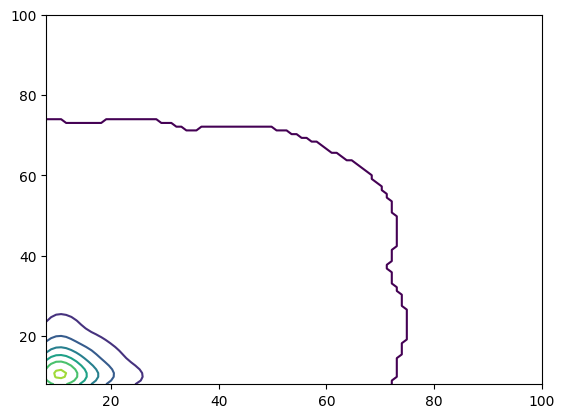

In [96]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.contour(ma, mb, pp_1g1g.reshape(100, 100))

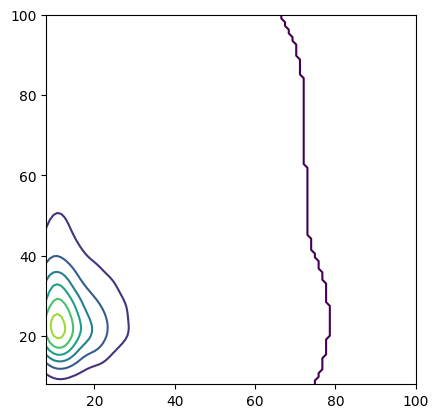

In [97]:
fig, ax = plt.subplots()
ax.contour(ma, mb, pp_1g2g.reshape(100, 100))
ax.set_box_aspect(1)

In [98]:
def order_wrap(kde):

    def prob(x):
        """ x = [m1, m2] """
        prob = kde.pdf(x) + kde.pdf(x[::-1])
        return prob * (x[0] >= x[1])

    return prob

In [99]:
a = jnp.linspace(0, 1, 100)
b = jnp.linspace(2, 3, 100)

jnp.column_stack([a, b]).shape

(100, 2)

In [102]:
mm.shape

(10000, 2)

In [1]:
from data import get_data
_, posteriors, injections, ln_evidences = get_data(
    snr_thresh=10,
    far_thresh=1,
    prefer_xphm=False,
    prefer_xphm_gwtc3=True,
    return_ln_evidence=True
)

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5


In [2]:
post_m1 = posteriors['mass_1']
post_m2 = post_m1 * posteriors['mass_ratio']

In [3]:
post_m1.shape

(153, 6913)

In [5]:
import jax.numpy as jnp

In [17]:
jnp.stack([post_m1.ravel(), post_m2.ravel()], axis=-1)

Array([[34.904243, 28.706694],
       [31.782192, 30.576708],
       [34.780754, 30.232851],
       ...,
       [29.250586, 15.795103],
       [36.009544, 19.41455 ],
       [34.42163 , 16.770227]], dtype=float32)

In [19]:
post_m1[-1, -1], post_m2[-1, -1]

(np.float64(34.421631961127346), np.float64(16.77022703452244))

In [16]:
jnp.stack([
    post_m1,
    post_m2
]).transpose(1, 2, 0).reshape(153 * 6913, 2)

Array([[34.904243, 28.706694],
       [31.782192, 30.576708],
       [34.780754, 30.232851],
       ...,
       [29.250586, 15.795103],
       [36.009544, 19.41455 ],
       [34.42163 , 16.770227]], dtype=float32)

In [119]:
post_m1

array([[34.90424173, 31.7821926 , 34.78075579, ..., 32.40410484,
        38.27086819, 37.81207449],
       [29.66274623, 22.90904947, 19.10687173, ..., 19.64571789,
        42.52284106, 21.560132  ],
       [12.95822666, 10.07653814, 11.98672838, ..., 10.92832095,
        13.10643817, 13.34223486],
       ...,
       [49.30187462, 41.72873531, 47.99083476, ..., 56.67080515,
        44.32060884, 33.32086753],
       [53.17168446, 66.65746163, 84.32827827, ..., 56.10718061,
        34.60086231, 76.06109681],
       [28.45881993, 33.9690292 , 34.81652042, ..., 29.25058583,
        36.00954572, 34.42163196]], shape=(153, 6913))

In [121]:
post_m2

array([[28.7066939 , 30.5767082 , 30.23285175, ..., 32.02938612,
        26.27376634, 27.04467919],
       [11.99575578, 12.68428156, 15.55996627, ..., 19.15447967,
         7.64998981, 19.15694414],
       [ 7.59826772,  9.81397521,  8.35448104, ...,  9.53905235,
         8.19452191,  7.56128626],
       ...,
       [20.76924135, 27.10133349, 37.20348646, ..., 19.82042895,
        30.54402692, 30.44046734],
       [45.77463367, 65.63060035, 11.83807452, ..., 33.06745688,
        28.132065  , 33.69136148],
       [16.8340396 , 15.004056  , 16.28319278, ..., 15.79510266,
        19.41454988, 16.77022703]], shape=(153, 6913))

In [118]:
jnp.stack([post_m1, post_m2]).reshape(-1, 2)

Array([[34.904243, 31.782192],
       [34.780754, 34.476166],
       [33.186153, 40.144375],
       ...,
       [16.506792, 21.998821],
       [17.0305  , 15.795103],
       [19.41455 , 16.770227]], dtype=float32)

In [115]:
jnp.column_stack([post_m1, post_m2]).reshape(
    post_m1.shape[0] * post_m1.shape[1], 2
)

Array([[34.904243, 31.782192],
       [34.780754, 34.476166],
       [33.186153, 40.144375],
       ...,
       [16.506792, 21.998821],
       [17.0305  , 15.795103],
       [19.41455 , 16.770227]], dtype=float32)

In [ ]:
x = 

In [101]:
jax.vmap(order_wrap(kde_1g1g))(mm)

Array([[0.00701718],
       [0.        ],
       [0.        ],
       ...,
       [0.        ],
       [0.        ],
       [0.        ]], dtype=float32)

In [73]:
pp_1g1g = jax.vmap(order_wrap(kde_1g1g))(mm).reshape(100, 100)

In [74]:
pp_1g2g = jax.vmap(order_wrap(kde_1g2g))(mm).reshape(100, 100)

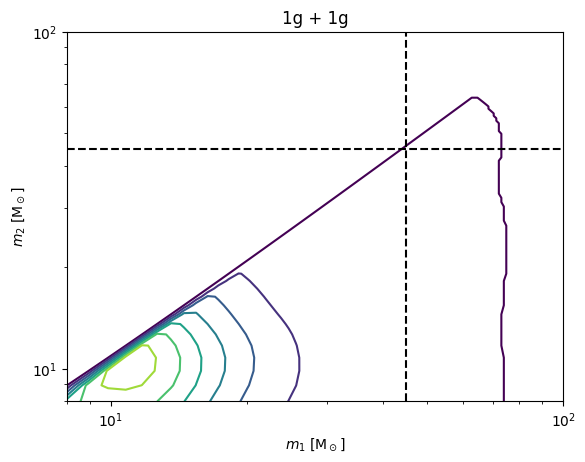

In [75]:
fig, ax = plt.subplots()
c = ax.contour(ma, mb, pp_1g1g) #norm='log', vmin=1e-3, vmax=1e-2)
ax.loglog()

ax.set_title('1g + 1g')
ax.set_xlabel(r'$m_1$ [$\mathrm{M}_\odot$]')
ax.set_ylabel(r'$m_2$ [$\mathrm{M}_\odot$]')

ax.axhline(y=45, linestyle='--', color='black')
ax.axvline(x=45, linestyle='--', color='black')

Text(0.5, 1.0, '1g + 2g')

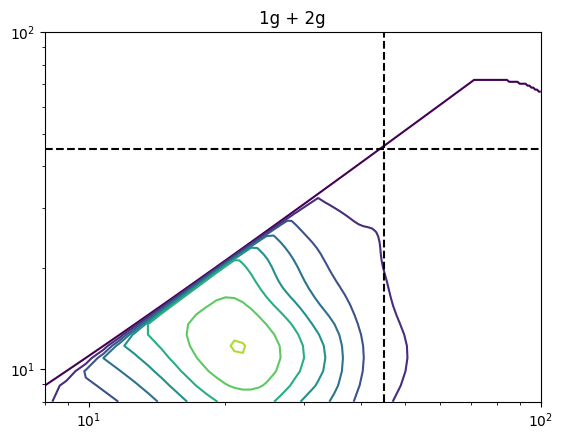

In [81]:
fig, ax = plt.subplots()
ax.contour(ma, mb, pp_1g2g)
ax.loglog()

ax.axhline(y=45, linestyle='--', color='black')
ax.axvline(x=45, linestyle='--', color='black')

ax.set_title('1g + 2g')

In [77]:
p_m1_1g2g = jnp.trapezoid(pp_1g2g, m, axis=1)
p_m2_1g2g = jnp.trapezoid(pp_1g2g, m, axis=0)

Text(0.5, 1.0, '1g + 2g')

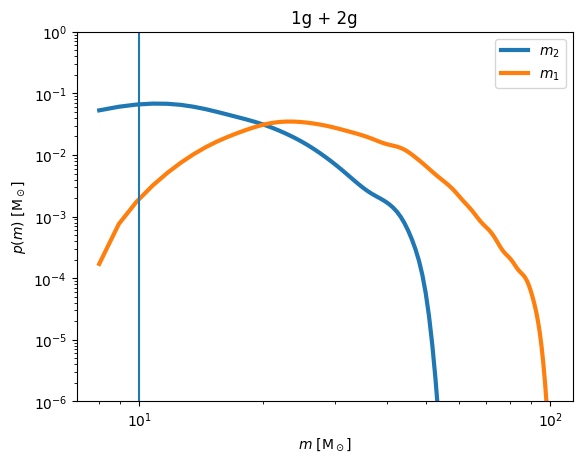

In [88]:
fig, ax = plt.subplots()

ax.plot(m, p_m2_1g2g, label=r'$m_2$', lw=3)
ax.plot(m, p_m1_1g2g, label=r'$m_1$', lw=3)

ax.axvline(x=10)

ax.loglog()

ax.set_ylim(1e-6, 1e0)

ax.set_xlabel(r'$m$ [$\mathrm{M}_\odot$]')
ax.set_ylabel(r'$p(m)$ [$\mathrm{M}_\odot$]')

ax.legend()

ax.set_title('1g + 2g')

In [5]:
kde_1g1g.pdf()

Signature: kde_1g1g.pdf(x)
Docstring: Probability density function
File:      /work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/jax/_src/scipy/stats/kde.py
Type:      method

In [2]:
import numpy as np

def build_interp_sampler(density, xs, xp=jnp):
    """ factory-function for inverse CDF sampling by interpolated a density
        over points xp. """
    if xp == jnp:
        from quadax import cumulative_trapezoid
    else:
        from scipy.integrate import cumulative_trapezoid

    prob = density(xs)
    norm = xp.trapezoid(prob, xs)
    prob /= norm

    cdf = cumulative_trapezoid(y=prob, x=xs, initial=0)

    if xp == jnp:
        def func(key):
            u = jax.random.uniform(key)
            return xp.interp(u, cdf, xs)
    elif xp == np:
        def func(rng, size=()):
            u = rng.uniform(size=size)
            return xp.interp(u, cdf, xs)

    return func

In [3]:
def log_bpl_progenitor_mass(mprog, alpha_1, alpha_2, mmin, mmax, mbreak):
    """ broken powerlaw in progenitor masses """
    break_fraction = (mbreak - mmin) / (mmax - mmin)
    return BrokenPowerLaw(
        mprog, -alpha_1, -alpha_2, mmin, mmax, break_fraction
    )


mprog_min = 8
mprog_max = 100
mprog_break = 50


ms = jnp.linspace(
    mprog_min,
    mprog_max,
    500
)

sample_mprog = build_interp_sampler(
    lambda x: jnp.exp(log_bpl_progenitor_mass(
        x,
        2.1, #parameters['alpha_prog_1'],
        1.1, #parameters['alpha_prog_2'],
        mprog_min,
        mprog_max,
        mprog_break,
    )),
    ms
)

In [4]:
from jax.scipy.stats import gaussian_kde

mbhmax = 45
mturnover = 35

def sample_mbh(key):
    mprog = sample_mprog(key)
    return remnant_mass_golomb2023(mprog, mbhmax, mturnover)


def sample_and_fit_m1g(key, n=100):
    mbh = jax.vmap(sample_mbh)(jax.random.split(key, n))
    return mbh, gaussian_kde(mbh, weights=mbh > 0)

In [5]:
mbh, kde = sample_and_fit_m1g(jax.random.key(1))

In [6]:
def sample_mb_and_weight(key, ma, beta=-1.1):
    mb = kde.resample(key)
    weight = (ma + mb)**(beta)
    return mb, weight

In [44]:
def sample_ma_and_mb_and_weight(key, beta=-1.1):
    ms = kde.resample(key, (2,))
    ms = ms.squeeze()
    weight = jnp.sum(ms)**beta
    return ms, weight

In [45]:
ms, weights = jax.vmap(sample_ma_and_mb_and_weight)(jax.random.split(jax.random.key(6), 1_000))
mtots = jnp.sum(ms, axis=1)

In [13]:
def farter(key):
    return jax.random.uniform(key, (2,))

m1, m2 = jax.vmap(farter)(jax.random.split(jax.random.key(1), 100)).T

In [46]:
kde_mtot = gaussian_kde(mtots, weights=weights)

In [47]:
def sample_m1g_and_m2g_and_weight(key, beta=-1.1):
    key, subkey = jax.random.split(key)
    m1g = kde.resample(key).squeeze()

    key, subkey = jax.random.split(key)
    m2g = kde_mtot.resample(subkey).squeeze()

    weight = (m1g + m2g)**beta

    return jnp.array([m1g, m2g]), weight

In [48]:
ms_1g2g, weights_1g2g = jax.vmap(sample_m1g_and_m2g_and_weight)(jax.random.split(jax.random.key(7), 1_000))

In [49]:
ms_1g2g_sorted = jnp.sort(ms_1g2g, axis=1)
ms_1g2g_sorted = ms_1g2g_sorted[:, ::-1]

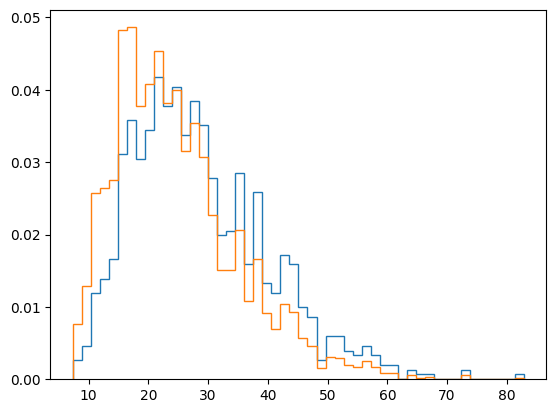

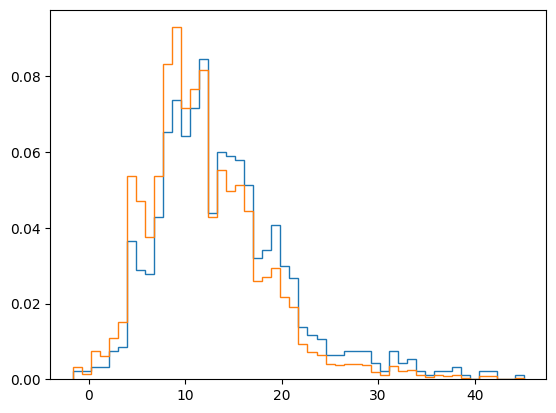

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(
    ms_1g2g_sorted[:, 0],
     histtype='step',
    bins=50,
    density=True
)

ax.hist(
    ms_1g2g_sorted[:, 0],
    weights=weights_1g2g,
    histtype='step',
    bins=50,
    density=True
);

fig, ax = plt.subplots()

ax.hist(
    ms_1g2g_sorted[:, 1],
     histtype='step',
    bins=50,
    density=True
)

ax.hist(
    ms_1g2g_sorted[:, 1],
    weights=weights_1g2g,
    histtype='step',
    bins=50,
    density=True
);

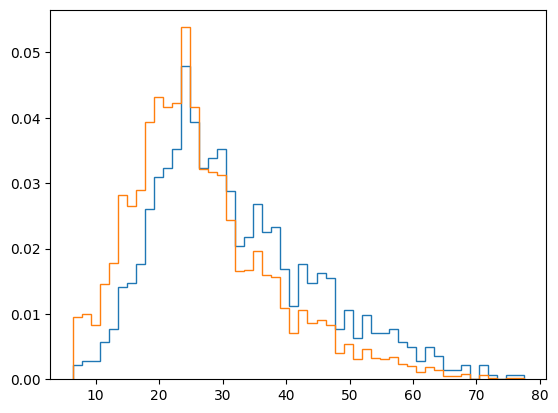

In [51]:
fig, ax = plt.subplots()
ax.hist(mtots, histtype='step', bins=50, density=True)
ax.hist(mtots, histtype='step', bins=50, density=True, weights=weights);

In [41]:
sample_ma_and_mb_and_weight(jax.random.key(1))

(Array([ 8.735994, 14.89629 ], dtype=float32), Array(32.423233, dtype=float32))

In [146]:
n = 100

ma = kde.resample(jax.random.key(5), (n,)) #jax.vmap(kde.resample)(jax.random.split(jax.random.key(5), 100))

# TODO: probably worth re-drawing from our density estimator, so everything is self-consistent

ma_tiled = jnp.tile(ma, (100, 1)).T

keys = jax.random.split(jax.random.key(2), n * n).reshape(n, n)

mb, weight = jax.vmap(jax.vmap(lambda x: sample_mb_and_weight(*x)))(
    (
        keys,
        ma_tiled
    )
)

mb = mb.squeeze()
weight = weight.squeeze()

In [147]:
keys = jax.random.split(jax.random.key(3), n)

u = jax.vmap(lambda k: jax.random.uniform(k, (n,)))(keys)
u *= jnp.max(weight, axis=0)

keep = weight < u

In [152]:
ma_tiled.min()

Array(2.6620197, dtype=float32)

In [148]:
mtots = ma_tiled + mb

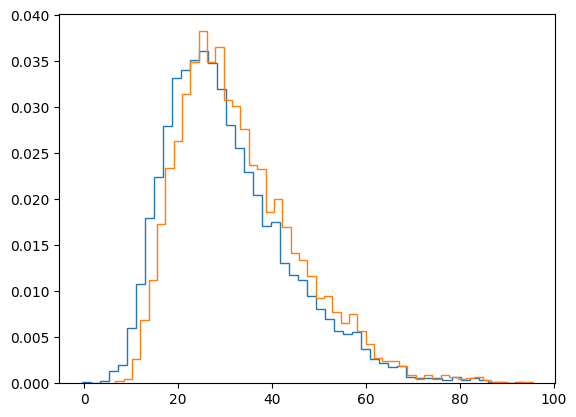

In [149]:
fig, ax = plt.subplots()

ax.hist(mtots.flatten(), histtype='step', bins=50, density=True)
ax.hist(mtots[keep], histtype='step', bins=50, density=True);

In [150]:
mtots.min()

Array(-0.55461407, dtype=float32)

In [109]:
jnp.tile(ma, (100, 1)).T[0]

Array([22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 22.409077, 22.409077,
       22.409077, 22.409077, 22.409077, 22.409077, 

In [86]:
mb

<function __main__.<lambda>(k)>

In [ ]:
mas = jnp.linspace(8, 100, 100)
mbs = jnp.linspace(8, 100, 100)

mma, mmb = jnp.meshgrid(mas, mbs, indexing='ij')



In [72]:
def logtrapz(log_y, x=None, dx=1.0, axis=-1):
    import math
    import jax.numpy as jnp
    from jax.scipy.special import logsumexp
    """
    Integrate y values that are given in log space.

    Parameters
    ----------
    log_y : array_like
        Natural logarithm of input `n`-dimensional array to integrate.
    x : array_like, optional
        The sample points corresponding to the `log_y` values.
        If `x` is None, the sample point are assumed to be evenly spaced `dx` apart.
        The default is None.
    dx : scalar, optional
        The spacing between the sample points when `x` is None.
        The default is 1.
    axis : int, optional
        The axis along which to integrate.

    Returns
    -------
    float or ndarray
        Natural logarithm of the definite integral of `exp(log_y)`.
        If `log_y` is a 1-dimensional array, then the result is a float.
        If `n` is greater than 1, then the result is an `n`-1 dimensional array.
    """

    # This first part is taken from np.trapz
    # https://github.com/numpy/numpy/blob/v1.24.0/numpy/lib/function_base.py#L4773-L4884

    log_y = jnp.asarray(log_y)
    nd = log_y.ndim

    if x is None:
        d = dx
    else:
        x = jnp.asarray(x)
        if x.ndim == 1:
            d = jnp.diff(x)
            shape = [1] * nd
            shape[axis] = d.shape[0]
            d = d.reshape(shape)
        else:
            d = jnp.diff(x, axis=axis)

    slice1 = [slice(None)] * nd
    slice2 = [slice(None)] * nd
    slice1[axis] = slice(1, None)
    slice2[axis] = slice(None, -1)
    slice1 = tuple(slice1)
    slice2 = tuple(slice2)

    # Now we write the trapezoidal rule in log space

    log_integrand = logsumexp(
        jnp.array([log_y[slice1], log_y[slice2]]),
        axis=0,
        ) + jnp.log(d)
    log_integral = logsumexp(log_integrand, axis=axis) - math.log(2)

    return log_integral


goal:

$$ p(m' | m) \propto p(m')(m' + m)^\beta $$

whose normalization $N$ depends on $m$,

$$N(m) = \int d m' p(m' | m)$$

We can do the usual thing and interpolate $N$ as a function of $m$.

In [76]:
mas = jnp.linspace(8, 100, 100)
mbs = jnp.linspace(8, 100, 100)

mma, mmb = jnp.meshgrid(mas, mbs, indexing='ij')

beta = 1.1

log_p_m_b = (
    jax.vmap(jax.vmap(kde.logpdf))(mmb).squeeze()
    + (mma + mmb)**(beta)
)

log_norm = logtrapz(log_p_m_b, mbs, axis=1)

So, now we can sample $m_a \sim p(\cdot)$ (from the KDE) and $m_b \sim p(\cdot | m_a)$ (rejection sampling)

In [81]:
new_m_a = kde.resample(jax.random.key(4))



log_norm_given_new_m_a = jnp.interp(new_m_a, mas, log_norm)
log_p_m_b_given_new_m_a = kde.logpdf( + log_norm_given_new_m_a

In [83]:
log_p_m_b_given_new_m_a

Array([[112.25917 , 113.74667 , 115.19186 , ..., 129.74792 , 127.01098 ,
        124.20199 ],
       [113.611855, 115.106804, 116.55908 , ..., 131.37842 , 128.64291 ,
        125.83532 ],
       [114.971985, 116.47403 , 117.9331  , ..., 133.01035 , 130.27625 ,
        127.47004 ],
       ...,
       [260.3755  , 262.14084 , 263.85782 , ..., 293.3097  , 290.67578 ,
        287.96927 ],
       [262.006   , 263.77277 , 265.49115 , ..., 295.04324 , 292.41016 ,
        289.70444 ],
       [263.63794 , 265.4061  , 267.12585 , ..., 296.77765 , 294.14536 ,
        291.44043 ]], dtype=float32)

In [78]:
new_m_a

Array([11.333692], dtype=float32)

(100, 100, 1)

In [67]:
jnp.vectorize(kde.logpdf, signature='(m,n)->(m,n)')(mmb)

ValueError: points have dimension 100, dataset has dimension 1

In [55]:



mm_tot = mma + mmb

beta = 1.1

log_prob = kde.logpdf(mma) + kde.logpdf(mmb) + mm_tot**beta

ValueError: points have dimension 100, dataset has dimension 1

$$ p(m_a) p(m_b) (m_a + m_b)^\beta $$

In [42]:
m1g = mbh.copy()

In [43]:
from tqdm import trange
from pixelpop.models.gwpop_models import powerlaw
from pixelpop.models.gwpop_models import trunc_gaussian

alpha = 1.1

m2g = []
merged = []

m1_1g1g = []
m2_1g1g = []

key = jax.random.key(3)

for i in trange(len(mbh)):
    if i in merged:
        continue

    ma = m1g[i]

    if not ma > 0:
        continue

    for j in range(i + 1, len(mbh)):
        if j in merged:
            continue

        mb = m1g[j]

        if not mb > 0:
            continue

        mtot = ma + mb

        p_merge = jnp.exp(powerlaw(mtot, alpha, 16, 200))

        key, subkey = jax.random.split(key)
        u = jax.random.uniform(subkey)

        if u <= p_merge:
            m2g.append(mtot)
            merged += [i, j]
            m2, m1 = jnp.sort(jnp.array([ma, mb]))
            m1_1g1g.append(m1)
            m2_1g1g.append(m2)
            break

100%|██████████| 100/100 [00:04<00:00, 20.62it/s]


In [49]:
m_1g_and_2g = jnp.concatenate([
    jnp.array([m for i, m in enumerate(m1g) if i not in merged]),
    jnp.array(m2g)
])

In [ ]:
for i in trange(len(m_1g_and_2g)):
    if i in merged:
        continue

    ma = mbh[i]

    if not ma > 0:
        continue

    for j in range(i + 1, len(m_1g_and_2g)):
        if j in merged:
            continue

        mb = mbh[j]

        if not mb > 0:
            continue

        mtot = ma + mb

        p_merge = jnp.exp(powerlaw(mtot, alpha, 16, 200))

        key, subkey = jax.random.split(key)
        u = jax.random.uniform(subkey)

        if u <= p_merge:
            m2g.append(mtot)
            merged += [i, j]
            m2, m1 = jnp.sort(jnp.array([ma, mb]))
            m1_1g1g.append(m1)
            m2_1g1g.append(m2)
            break

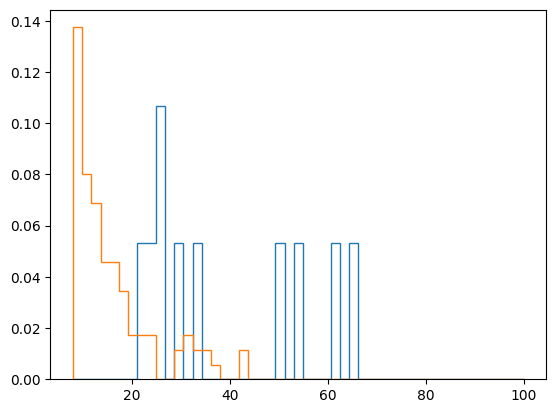

In [38]:
import matplotlib.pyplot as plt

bins = np.linspace(8, 100, 50)

fig, ax = plt.subplots()
ax.hist(m2g, histtype='step', bins=bins, density=True)
ax.hist(mbh, histtype='step', bins=bins, density=True);

(10000,)

In [ ]:
beta = 1.1


def sample_stupid(key):
    key, subkey = split(key)
    mbh_a = sample_mbh(subkey)

    key, subkey = split(key)
    mbh_b = sample_mbh(subkey)

    m1, m2 = jnp.sort(jnp.array([mbh_a, mbh_b]))
    q = m2 / m1



#    key, subkey = split(key)
#    u = jax.random.uniform(subkey)
#
#    p_q = jnp.exp(powerlaw(q, beta, 0.1, 1.0))
#
#    if u < q**beta:
        
    

In [ ]:
mbh

In [12]:
# write it the stupid way first

n = 100
ms = jnp.linspace(8, 100, n)

# norm at each m1
norm = []

for i in range(n):
    m1 = ms[i]
    q = m1 / ms
    
    #for j in range(n):
        

Text(0.5, 0, '$m_\\mathrm{BH}$ [$\\mathrm{M}_\\odot$]')

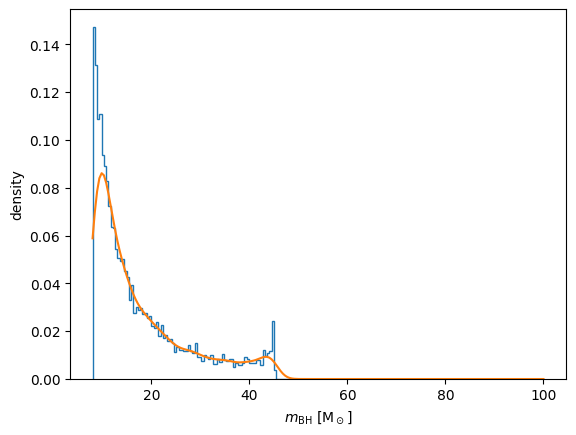

In [8]:
import matplotlib.pyplot as plt

xs = jnp.linspace(8, 100, 200)

fig, ax = plt.subplots()
ax.hist(mbh, histtype='step', bins=xs, density=True);

ax.plot(xs, kde(xs))

ax.set_ylabel('density')
ax.set_xlabel(r'$m_\mathrm{BH}$ [$\mathrm{M}_\odot$]')

In [ ]:
from jax.random import split

def sample_mbh_1g(key):
    mprog = sample_mprog(key)
    return remnant_mass_golomb2023(mprog, mbhmax, mturnover)


def sample_mbh_2g(key):
    key, subkey = split(key)
    
    
    
    mprog = sample_mprog(key)
    return remnant_mass_golomb2023(mprog, mbhmax, mturnover)

In [10]:
kde.resample(jax.random.key(2))

Array([14.266596], dtype=float32)

Array(22.409077, dtype=float32)

In [9]:
jnp.meshgrid(mbh, mbh, indexing='ij')

[Array([[22.409077, 22.409077, 22.409077, ..., 22.409077, 22.409077,
         22.409077],
        [12.528909, 12.528909, 12.528909, ..., 12.528909, 12.528909,
         12.528909],
        [16.14827 , 16.14827 , 16.14827 , ..., 16.14827 , 16.14827 ,
         16.14827 ],
        ...,
        [ 9.918498,  9.918498,  9.918498, ...,  9.918498,  9.918498,
          9.918498],
        [17.894695, 17.894695, 17.894695, ..., 17.894695, 17.894695,
         17.894695],
        [18.723555, 18.723555, 18.723555, ..., 18.723555, 18.723555,
         18.723555]], dtype=float32),
 Array([[22.409077, 12.528909, 16.14827 , ...,  9.918498, 17.894695,
         18.723555],
        [22.409077, 12.528909, 16.14827 , ...,  9.918498, 17.894695,
         18.723555],
        [22.409077, 12.528909, 16.14827 , ...,  9.918498, 17.894695,
         18.723555],
        ...,
        [22.409077, 12.528909, 16.14827 , ...,  9.918498, 17.894695,
         18.723555],
        [22.409077, 12.528909, 16.14827 , ...,  9.918498,

In [ ]:
@jax.jit
def sample_and_fit_m1g(key):
    mbh = jax.vmap(sample_mbh)(jax.random.split(key, 10_000))
    
    
    #return mbh, gaussian_kde(mbh, weights=mbh > 0)